# Affichage des Donnees pour MLP

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


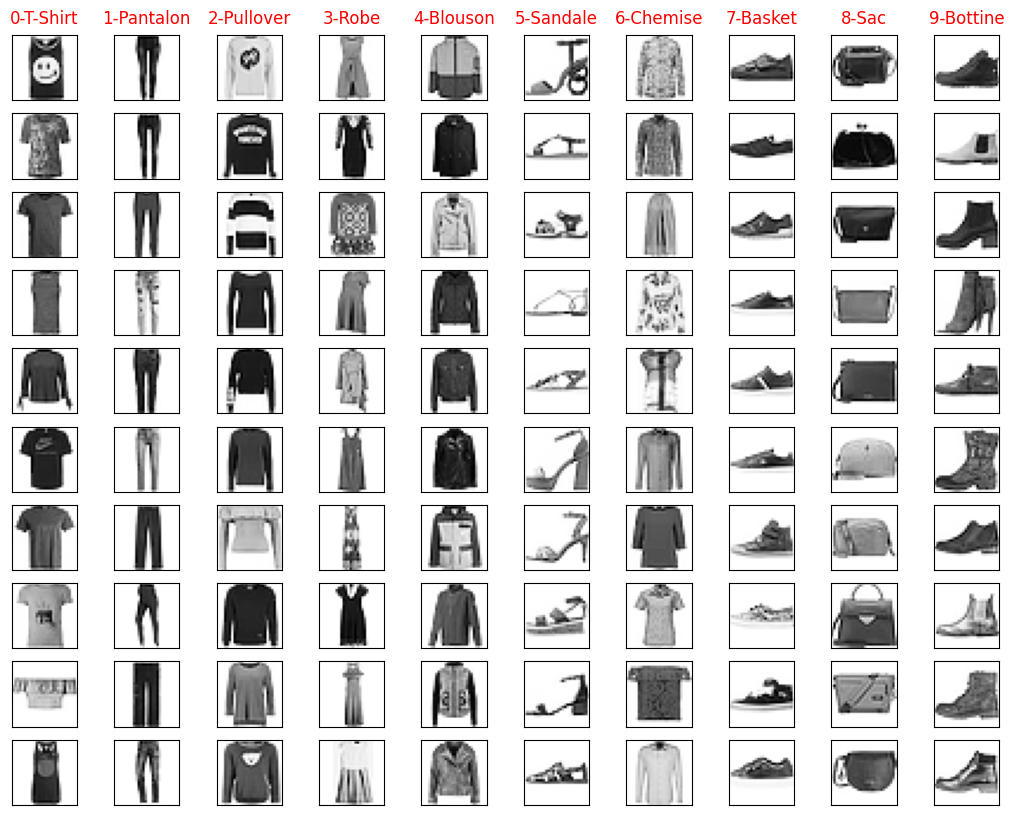

In [1]:
#----------------------------------------------------------------------------
#  Reconnaissance d'images de vêtements et articles de mode (Fashion_MNIST)
#
# Programme pour charger la base en mémoire et afficher des exemples d'images
#----------------------------------------------------------------------------

# Importation des Modules
import numpy as np               # Manipulation de tableaux
import tensorflow as tf          # Manipulation de tenseurs
import matplotlib.pyplot as plt  # Tracé de graphiques

#----------------------------------------------------------------------------
# Chargement des données du Dataset Fashion_MNIST
#  => 4 tableaux de type ndarray (NumPy) avec des valeurs entières
#   x_train : (60000,28,28,1)
#   y_train : (60000,1)
#   x_test  : (10000,28,28,1)
#   y_test  : (10000,1)
#----------------------------------------------------------------------------
(x_train,y_train), (x_test,y_test) = tf.keras.datasets.fashion_mnist.load_data()

#----------------------------------------------------------------------------
# Affichage d'exemples d'images de la base Fashion_MNIST
#----------------------------------------------------------------------------
plt.figure(figsize=(13,10))
# Dictionnaire avec les numéros et les noms des labels
Labels = {0:'T-Shirt', 1:'Pantalon', 2:'Pullover', 3:'Robe', 4:'Blouson',\
          5:'Sandale', 6:'Chemise',  7:'Basket',   8:'Sac',9  :'Bottine'}
# Parcours des labels
for NoLabel,NomLabel in Labels.items():
    iImg=100   # début
    # Pour chaque label affichage de 10 images
    for NoImage in range(10):
        iImg += 1
        # Recherche et affichage d'images référencées avec 'NoLabel'
        while y_train[iImg] != NoLabel: iImg+=1
        plt.subplot(10,10,10*NoImage+NoLabel+1)
        plt.imshow(x_train[iImg], cmap='Greys')
        # suppression des graduations sur les axes X et Y
        plt.xticks(ticks=[])
        plt.yticks(ticks=[])
        # affichage des information sur les labels
        if NoImage == 0:
            plt.title('{}-{}'.format(NoLabel,NomLabel),
                      pad=8,size=12,
                      color='Red')

# Affichage de la figure
plt.show()

# Implémentation et entraînement d’un MLP (Base)

Implémenter un réseau de neurones multicouches (MLP) pour la classification des images du dataset Fashion_MNIST. Les images sont d’abord normalisées et transformées en vecteurs de 784 caractéristiques. Le modèle comprend une couche cachée de 50 neurones avec fonction d’activation ReLU, suivie d’une couche de sortie de 10 neurones avec Softmax pour prédire les 10 classes. Le réseau est ensuite entraîné pendant plusieurs epochs, puis évalué à l’aide des métriques accuracy et loss sur les données de test, afin d’obtenir une première baseline de performance.

In [2]:
#----------------------------------------------------------------------------
# Changements de format pour exploitation
#----------------------------------------------------------------------------
# Transformation des valeurs associées en valeurs réelles entre 0.0 et 1.0
x_train, x_test = x_train / 255.0, x_test / 255.0

print(f"Train images shape: {x_train.shape}") #(60000, 28, 28)
print(f"Test images shape: {x_test.shape}") #(10000, 28, 28)

# Transformation des données en vecteurs de 28x28=784 pixels
x_train = x_train.reshape(60000, 784)
x_test  = x_test.reshape(10000, 784)

# Transformation des données de sortie en vecteurs booléens pour
# une classification en 10 valeurs
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test  = tf.keras.utils.to_categorical(y_test, 10)

#----------------------------------------------------------------------------
# Modèle Perceptron multicouches (MLP) de base
# 1 couche cachée avec 50 neurones
#----------------------------------------------------------------------------
# Création d'un réseau multicouches
MonReseau = tf.keras.Sequential()

# Description de la 1ère couche cachée
MonReseau.add(tf.keras.layers.Dense(
        units=50,              # 50 neurones
        input_shape=(784,),    # nombre d'entrées (car c'est la 1ère couche)
        activation='relu'))    # fonction d'activation

# Description de la 1ère couche cachée
MonReseau.add(tf.keras.layers.Dense(
        units=10,              # 10 neurones
        activation='softmax')) # fonction d'activation (sorties sur [0,1])

# Configuration de la procédure pour l'apprentissage
MonReseau.compile(optimizer='adam',                # algo d'apprentissage
                  loss='categorical_crossentropy', # mesure de l'erreur
                  metrics=['accuracy'])            # mesure du taux de succès

# Calcul des paramètres du réseau à partir des exemples
hist=MonReseau.fit(x=x_train, # données d'entrée pour l'apprentissage
                   y=y_train, # sorties désirées associées aux données d'entrée
                   epochs=10, # nombre de cycles d'apprentissage
                   validation_data=(x_test,y_test)) # données de test

# Résultat du réseau avec des données de tests
loss_base, acc_base = MonReseau.evaluate(
    x=x_test, # données d'entrée pour le test
    y=y_test,
    verbose=0) # sorties désirées pour le test

print(f"Accuracy du réseau de base: {acc_base:.4f}")
print(f"Loss du réseau de base: {loss_base:.4f}\n")

# Vérifie l'écart entre train et validation
ecart = max(hist.history['accuracy']) - max(hist.history['val_accuracy'])
print(f"Écart train/validation - Réseau de base : {ecart*100:.2f}%")


Train images shape: (60000, 28, 28)
Test images shape: (10000, 28, 28)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8187 - loss: 0.5243 - val_accuracy: 0.8400 - val_loss: 0.4462
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8578 - loss: 0.3934 - val_accuracy: 0.8488 - val_loss: 0.4279
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8705 - loss: 0.3597 - val_accuracy: 0.8550 - val_loss: 0.3960
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8781 - loss: 0.3365 - val_accuracy: 0.8641 - val_loss: 0.3776
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8848 - loss: 0.3188 - val_accuracy: 0.8656 - val_loss: 0.3733
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.8885 - loss: 0.3065 - val_accuracy: 0.8722 - val_loss: 0.3578
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8921 - loss: 0.2951 - val_accuracy: 0.8616 - val_loss: 0.3755
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8954 - loss: 0.2835 - 

## Optimisation du MLP - Architectures
Proposer et tester différentes architectures de MLP en faisant varier le nombre de couches cachées et le nombre de neurones par couche afin d’analyser leur impact sur les performances du modèle.

In [3]:
# On va tester 5 architectures différentes
architectures = [
    {"name": "2 couches (64,32) (activation: relu)", "layers": [64, 32]},  # 2 couches
    {"name": "3 couches (128,64,32) (activation: relu)", "layers": [128, 64, 32]},  # 3 couches
    {"name": "4 couches (256,128,64,32) (activation: relu)", "layers": [256, 128, 64, 32]},  # 4 couches
]

# Liste pour stocker les résultats
results = []

print("Test des différentes architectures")

# Pour chaque architecture dans notre liste
for arch in architectures:
    print(f"\nTest de l'architecture: {arch['name']}")

    # Création d'un nouveau modèle vide
    MonReseau_modifier = tf.keras.Sequential()

    # La première couche a besoin de connaître la forme des données d'entrée
    MonReseau_modifier.add(tf.keras.layers.Input(shape=(784,)))

    # Ajout de chaque couche cachée
    for neurons in arch["layers"]:
        MonReseau_modifier.add(tf.keras.layers.Dense(
            neurons,
            activation='relu'))

    # Toujours une couche de sortie avec 10 neurones (pour les 10 classes)
    MonReseau_modifier.add(tf.keras.layers.Dense(
        units=10,
        activation='softmax'))

    # Configuration de l'apprentissage
    MonReseau_modifier.compile(
        optimizer='adam',  # Algorithme d'optimisation
        loss='categorical_crossentropy',  # Calcul de l'erreur
        metrics=['accuracy']  # On mesure le taux de bonnes réponses
    )

    # Entraînement du modèle
    historique = MonReseau_modifier.fit(
        x=x_train,  # Images d'entraînement
        y=y_train,  # Labels d'entraînement
        epochs=10,  # 10 cycles d'apprentissage
        validation_data=(x_test, y_test),  # Données de test
    )

    # Meilleure accuracy et loss sur validation
    val_acc = max(historique.history['val_accuracy'])
    val_loss = max(historique.history['val_loss'])

    # Stockage des résultats
    results.append({
        'name': arch['name'],
        'architecture': arch['layers'],
        'val_acc': val_acc,
        'val_loss': val_loss
    })

print("\n Résultats des architectures")
for result in results:
    print(
        f"{result['name']:30} :\n"
        f"  Accuracy validation = {result['val_acc']:.4f}\n"
        f"  Loss validation     = {result['val_loss']:.4f}"
    )


Test des différentes architectures

Test de l'architecture: 2 couches (64,32) (activation: relu)
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8165 - loss: 0.5247 - val_accuracy: 0.8415 - val_loss: 0.4458
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8597 - loss: 0.3874 - val_accuracy: 0.8567 - val_loss: 0.3989
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8715 - loss: 0.3494 - val_accuracy: 0.8574 - val_loss: 0.3891
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8806 - loss: 0.3248 - val_accuracy: 0.8631 - val_loss: 0.3694
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8859 - loss: 0.3103 - val_accuracy: 0.8724 - val_loss: 0.3549
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8905 - loss: 0.2959 - val_accuracy: 0.8737 - val_loss: 0.3529
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8944 - loss: 0.2862 - val_accuracy: 0.8770 - val_loss: 

Notre exploration d'architectures révèle que l'architecture à 3 couches (128-64-32 neurones) offre le meilleur compromis performance/efficacité. Avec une accuracy de 88.50% et une loss de 0.4124, elle surpasse l'architecture à 2 couches tout en étant plus performante que l'architecture à 4 couches sur le plan de la loss. L'écart de performance avec l'architecture à 4 couches (88,51 %) est extrêmement faible, seulement 0,01 point de pourcentage. Une différence aussi minime ne compense pas l'augmentation significative de la complexité du modèle. En effet, ajouter une quatrième couche entraîne : davantage de paramètres à entraîner, un temps de calcul plus long, et un risque accru de surapprentissage, sans bénéfice perceptible en précision.

## Optimisation du MLP - Fonctions d'activation


L’objectif de cette expérience est de comparer l’impact de différentes fonctions d’activation sur les performances d’un réseau de neurones multicouches (MLP) pour la classification des images Fashion_MNIST.

In [4]:
print("Test des fonctions d'activation")

# Les 3 fonctions d'activation principales
# activations = ['relu', 'sigmoid', 'tanh','elu','selu','linear','exponential','hard_sigmoid','softplus','softsign','swish','softmax']
activations = ['relu', 'sigmoid', 'tanh']

# On teste chaque fonction d'activation
for act in activations:
    print(f"\nTest avec activation: {act}")

    # Création d'un nouveau modèle vide
    MonReseau_modifier = tf.keras.Sequential()

    # Description de la 1ère couche cachée
    MonReseau_modifier.add(tf.keras.layers.Dense(
            units=128,          # 128 neurones
            input_shape=(784,), # nombre d'entrées (car c'est la 1ère couche)
            activation=act))    # fonction test

    # Description de la 2ème couche cachée
    MonReseau_modifier.add(tf.keras.layers.Dense(
            units=64,           # 64 neurones
            activation=act))    # fonction test

    # Description de la 3ème couche cachée
    MonReseau_modifier.add(tf.keras.layers.Dense(
            units=32,           # 32 neurones
            activation=act))    # fonction test

    # Description de la couche de sortie
    MonReseau_modifier.add(tf.keras.layers.Dense(
            units=10,              # 10 neurones
            activation='softmax')) # fonction softmax

    # Configuration de la procédure pour l'apprentissage
    MonReseau_modifier.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy'])

    # Entraînement
    historique = MonReseau_modifier.fit(
        x=x_train,
        y=y_train,
        epochs=10,
        validation_data=(x_test, y_test),
        verbose=0) # Pas d'affichage

    # Meilleure accuracy et loss sur validation
    val_acc = max(historique.history['val_accuracy'])
    val_loss = max(historique.history['val_loss'])

    print(f"Accuracy validation avec {act}: {val_acc:.4f}")
    print(f"loss validation avec {act}: {val_loss:.4f}")

Test des fonctions d'activation

Test avec activation: relu
Accuracy validation avec relu: 0.8848
loss validation avec relu: 0.4185

Test avec activation: sigmoid
Accuracy validation avec sigmoid: 0.8783
loss validation avec sigmoid: 0.4752

Test avec activation: tanh
Accuracy validation avec tanh: 0.8820
loss validation avec tanh: 0.4296


On compare relu, sigmoid et tanh. Relu donne de meilleurs résultats car elle évite le problème de vanishing gradient et accélère la convergence.

## Optimisation du MLP - Taux d'Apprentissage


Tester différentes valeurs pour le paramètre 'learning-rate' de l'algorithme Adam sur un MLP à trois couches cachées (128, 64, 32 neurones) pour la classification des images Fashion_MNIST. L'objectif est de trouver un taux d'apprentissage optimal pour une convergence rapide et stable.

In [ ]:
print("\nTest du learning rate")

# Différentes valeurs à tester
learning_rates = [0.1, 0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001, 0.00005, 0.00001]

for lr in learning_rates:
    print(f"\nTest avec learning rate: {lr}")

    # Création d'un nouveau modèle vide
    MonReseau_modifier = tf.keras.Sequential()

    # Description de la 1ère couche cachée
    MonReseau_modifier.add(tf.keras.layers.Dense(
            units=128,             # 128 neurones
            input_shape=(784,),    # nombre d'entrées (car c'est la 1ère couche)
            activation='relu'))    # fonction relu

    # Description de la 2ème couche cachée
    MonReseau_modifier.add(tf.keras.layers.Dense(
            units=64,              # 64 neurones
            activation='relu'))

    # Description de la 3ème couche cachée
    MonReseau_modifier.add(tf.keras.layers.Dense(
            units=32,              # 32 neurones
            activation='relu'))

    # Description de la couche de sortie
    MonReseau_modifier.add(tf.keras.layers.Dense(
            units=10,              # 10 neurones
            activation='softmax')) # fonction softmax

    MonReseau_modifier.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr), # learning-rate spécifié
        loss='categorical_crossentropy',
        metrics=['accuracy'])

    # Entraînement
    historique = MonReseau_modifier.fit(
        x=x_train,
        y=y_train,
        epochs=10,
        validation_data=(x_test, y_test),
        verbose=0) # Pas d'affichage

    # Meilleure accuracy et loss sur validation
    val_acc = max(historique.history['val_accuracy'])
    val_loss = historique.history['val_loss'][-1]

    print(f"Accuracy validation avec lr={lr}: {val_acc:.4f}")
    print(f"loss validation avec lr={lr}: { val_loss:.4f}")


Test du learning rate

Test avec learning rate: 0.1
Accuracy validation avec lr=0.1: 0.1000
loss validation avec lr=0.1: 2.3203

Test avec learning rate: 0.05
Accuracy validation avec lr=0.05: 0.1000
loss validation avec lr=0.05: 2.3091

Test avec learning rate: 0.01
Accuracy validation avec lr=0.01: 0.8554
loss validation avec lr=0.01: 0.4134

Test avec learning rate: 0.005
Accuracy validation avec lr=0.005: 0.8728
loss validation avec lr=0.005: 0.4032

Test avec learning rate: 0.001
Accuracy validation avec lr=0.001: 0.8832
loss validation avec lr=0.001: 0.3240

Test avec learning rate: 0.0005


Le learning rate contrôle la taille des pas lors de la descente de gradient. Un taux trop grand peut faire diverger, trop petit peut ralentir la convergence. Parmi les 9 valeurs testées, 0.0005 donnent la meilleure accuracy de validation et la plus faible loss.

## Optimisation du MLP - Cycles d'Apprentissage (Epochs)


Déterminer le nombre optimal de cycles d'apprentissage (epochs) sur un MLP à trois couches cachées (128, 64, 32 neurones) avec un learning rate fixé à 0.0005 pour la classification des images Fashion_MNIST. Cela permettra d'éviter le sous-apprentissage ou le surapprentissage.


In [6]:
print("Test de cycles d'apprentissage")

# Liste des nombres d'epoque à tester
epochs_list = [5, 15, 20, 25, 30]

# Pour stocker les résultats
results_epochs = []

for num_epochs in epochs_list:
    print(f"\nTest avec {num_epochs} epochs")

    # Création d'un nouveau modèle vide
    MonReseau_modifier = tf.keras.Sequential()

    # Description de la 1ère couche cachée
    MonReseau_modifier.add(tf.keras.layers.Dense(
            units=128,             # 128 neurones
            input_shape=(784,),    # nombre d'entrées (car c'est la 1ère couche)
            activation='relu'))    # fonction relu

    # Description de la 2ème couche cachée
    MonReseau_modifier.add(tf.keras.layers.Dense(
            units=64,              # 64 neurones
            activation='relu'))

    # Description de la 3ème couche cachée
    MonReseau_modifier.add(tf.keras.layers.Dense(
            units=32,              # 32 neurones
            activation='relu'))

    # Description de la couche de sortie
    MonReseau_modifier.add(tf.keras.layers.Dense(
            units=10,              # 10 neurones
            activation='softmax')) # fonction softmax

    MonReseau_modifier.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss='categorical_crossentropy',
        metrics=['accuracy'])

    # Entraîner
    historique = MonReseau_modifier.fit(
        x=x_train,
        y=y_train,
        epochs=num_epochs,  # Cycle d'apprentissage spécifié
        validation_data=(x_test, y_test),
        verbose=0)  # Pas d'affichage

    # Meilleure accuracy et loss sur validation
    val_acc = max(historique.history['val_accuracy'])
    val_loss = max(historique.history['val_loss'])

    # Calculer l'écart
    ecart = max(historique.history['accuracy']) - max(historique.history['val_accuracy'])

    print(f"Accuracy validation: {val_acc:.4f}")
    print(f"Loss validation: {val_loss:.4f}")
    print(f"Écart train/val: {ecart:.4f}")

Test de cycles d'apprentissage

Test avec 5 epochs
Accuracy validation: 0.8692
Loss validation: 0.4350
Écart train/val: 0.0211

Test avec 15 epochs
Accuracy validation: 0.8910
Loss validation: 0.4439
Écart train/val: 0.0321

Test avec 20 epochs
Accuracy validation: 0.8883
Loss validation: 0.4554
Écart train/val: 0.0448

Test avec 25 epochs
Accuracy validation: 0.8923
Loss validation: 0.4668
Écart train/val: 0.0465

Test avec 30 epochs
Accuracy validation: 0.8951
Loss validation: 0.4197
Écart train/val: 0.0544


Trop peu d'epochs sous-optimal, trop peut causer du surapprentissage. On essaie 5, 15, 20, 25, 30. L'analyse révèle que 15 epochs représente le point d'accuracy maximale (89.08%) pour notre modèle. Au-delà, l'accuracy stagne voire diminue légèrement (89.02% à 20 epochs, 89.06% à 25 epochs) tandis que le surapprentissage s'accélère significativement (+34% de 15 à 20 epochs, +60% de 15 à 25 epochs).

# Entraînement et Évaluation du MLP Final

In [7]:
#----------------------------------------------------------------------------
# Modèle Perceptron multicouches amélioré
# 3 couche cachée avec 128,64,32 neurones
# Fonction d'activation ReLu
# Learning-rate de 0.0005
# 15 cycle d'apprentissage
#----------------------------------------------------------------------------

# Création d'un réseau multicouches
MonReseau_ameliorer = tf.keras.Sequential()

# Description de la 1ère couche cachée
MonReseau_ameliorer.add(tf.keras.layers.Dense(
    units=128,             # 128 neurones
    input_shape=(784,),    # nombre d'entrées (car c'est la 1ère couche)
    activation='relu'))    # fonction relu

# Description de la 2ème couche cachée
MonReseau_ameliorer.add(tf.keras.layers.Dense(
    units=64,              # 64 neurones
    activation='relu'))

# Description de la 3ème couche cachée
MonReseau_ameliorer.add(tf.keras.layers.Dense(
    units=32,              # 32 neurones
    activation='relu'))

# Description de la couche de sortie
MonReseau_ameliorer.add(tf.keras.layers.Dense(
    units=10,              # 10 neurones
    activation='softmax')) # fonction softmax

MonReseau_ameliorer.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

# Entraîner
historique = MonReseau_ameliorer.fit(
    x=x_train,
    y=y_train,
    epochs=15,
    validation_data=(x_test, y_test))

# Évaluation sur les données de test
test_loss, test_acc = MonReseau_ameliorer.evaluate(
    x=x_test,
    y=y_test,
    verbose=0)

print(f"Accuracy du réseau de base: {acc_base:.4f}")
print(f"Loss du réseau de base: {loss_base:.4f}\n")
print(f"Accuracy du réseau amélioré: {test_acc:.4f}")
print(f"Loss du réseau de amélioré: {test_loss:.4f}\n")

# Calcul de l'amélioration
amelioration = ((test_acc - acc_base) / acc_base) * 100
print(f"Amélioration du acc : {amelioration:.4f}")

# Calcul de la réduction de la loss
reduction_loss = ((loss_base - test_loss) / loss_base) * 100
print(f"Réduction du loss : {reduction_loss:.4f}\n")

# Vérifie l'écart entre train et validation sur le MLP de base et MLP amélioré
ecart = max(hist.history['accuracy']) - max(hist.history['val_accuracy'])
print(f"Écart train/validation - Réseau de base : {ecart*100:.2f}%")

ecart = max(historique.history['accuracy']) - max(historique.history['val_accuracy'])
print(f"Écart train/validation -  Réseau amélioré : {ecart*100:.2f}%")


Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8118 - loss: 0.5391 - val_accuracy: 0.8361 - val_loss: 0.4569
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8605 - loss: 0.3896 - val_accuracy: 0.8375 - val_loss: 0.4368
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8748 - loss: 0.3450 - val_accuracy: 0.8668 - val_loss: 0.3742
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8829 - loss: 0.3202 - val_accuracy: 0.8693 - val_loss: 0.3595
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8888 - loss: 0.2996 - val_accuracy: 0.8715 - val_loss: 0.3698
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8950 - loss: 0.2856 - val_accuracy: 0.8699 - val_loss: 0.3539
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8986 - loss: 0.2729 - val_accuracy: 0.8741 - val_loss: 0.3658
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9027 - loss: 0.2618 - 

Notre modèle final, configuré avec une architecture à 3 couches (128-64-32 neurones), la fonction d'activation ReLU, un learning rate de 0.0005 et 15 epochs d'entraînement, atteint une accuracy de 89.09% sur l'ensemble de test. Cela représente une amélioration de 2.53 points par rapport au modèle de base (86.89%), accompagnée d'une réduction de 9.12% de la loss (0.3231 vs 0.3555).

Cette amélioration s'accompagne d'une augmentation tès maîtrisée du surapprentissage, l'écart train/validation passant de 2.18% à 3.30%. Cette valeur remarquablement basse pour une architecture complexe démontre l'excellente capacité de généralisation de notre modèle optimisé. Néanmoins, pour un déploiement industriel, l'ajout de techniques de régularisation légères (Dropout à 0.1-0.2) permettrait de réduire encore cet écart tout en conservant les performances exceptionnelles obtenues.

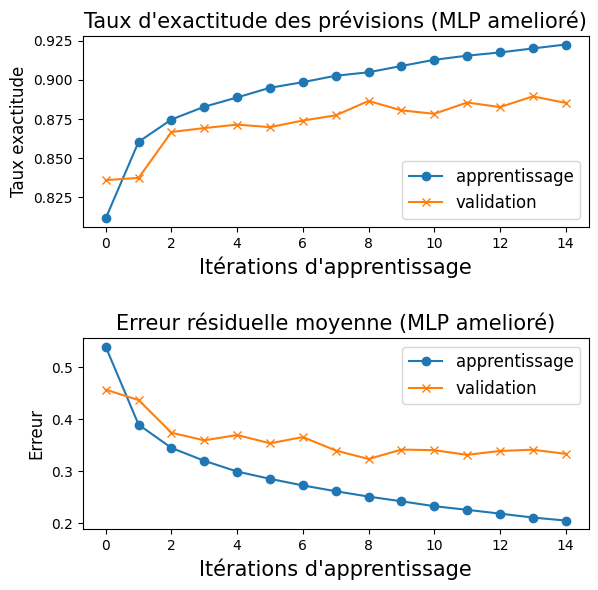

In [12]:
# création de la figure  du réseau modifié ('figsize' pour indiquer la taille)
plt.figure(figsize=(6,6))

# evolution du pourcentage des bonnes classifications
plt.subplot(2,1,1)
plt.plot(historique.history['accuracy'],'o-')
plt.plot(historique.history['val_accuracy'],'x-')
plt.title("Taux d'exactitude des prévisions (MLP amelioré)",fontsize=15)
plt.ylabel('Taux exactitude',fontsize=12)
plt.xlabel("Itérations d'apprentissage",fontsize=15)
plt.legend(['apprentissage', 'validation'], loc='lower right',fontsize=12)

# Evolution des valeurs de l'erreur résiduelle moyenne
plt.subplot(2,1,2)
plt.plot(historique.history['loss'],'o-')
plt.plot(historique.history['val_loss'],'x-')
plt.title('Erreur résiduelle moyenne (MLP amelioré)',fontsize=15)
plt.ylabel('Erreur',fontsize=12)
plt.xlabel("Itérations d'apprentissage",fontsize=15)
plt.legend(['apprentissage', 'validation'], loc='upper right',fontsize=12)

# espacement entre les 2 figures
plt.tight_layout(h_pad=2.5)
plt.show()

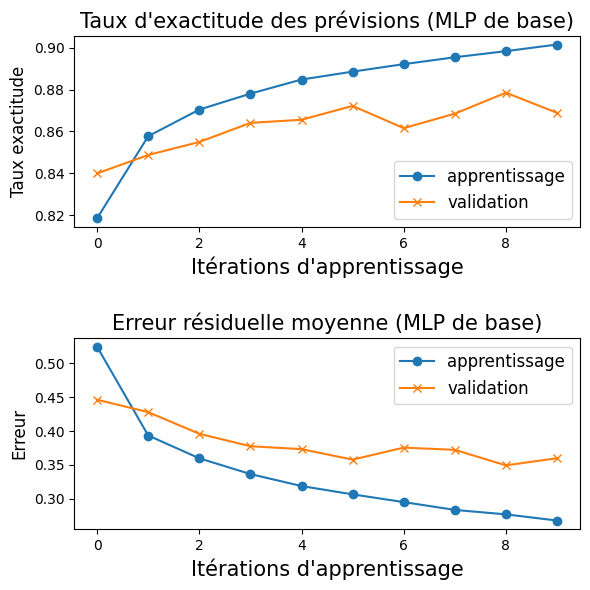

In [9]:
# création de la figure ('figsize' pour indiquer la taille)
plt.figure(figsize=(6,6))

# evolution du pourcentage des bonnes classifications
plt.subplot(2,1,1)
plt.plot(hist.history['accuracy'],'o-')
plt.plot(hist.history['val_accuracy'],'x-')
plt.title("Taux d'exactitude des prévisions (MLP de base)",fontsize=15)
plt.ylabel('Taux exactitude',fontsize=12)
plt.xlabel("Itérations d'apprentissage",fontsize=15)
plt.legend(['apprentissage', 'validation'], loc='lower right',fontsize=12)

# Evolution des valeurs de l'erreur résiduelle moyenne
plt.subplot(2,1,2)
plt.plot(hist.history['loss'],'o-')
plt.plot(hist.history['val_loss'],'x-')
plt.title('Erreur résiduelle moyenne (MLP de base)',fontsize=15)
plt.ylabel('Erreur',fontsize=12)
plt.xlabel("Itérations d'apprentissage",fontsize=15)
plt.legend(['apprentissage', 'validation'], loc='upper right',fontsize=12)

# espacement entre les 2 figures
plt.tight_layout(h_pad=2.5)
plt.show()

Visualisation des erreurs de classification :

Nombre d'erreurs trouvées : 1146


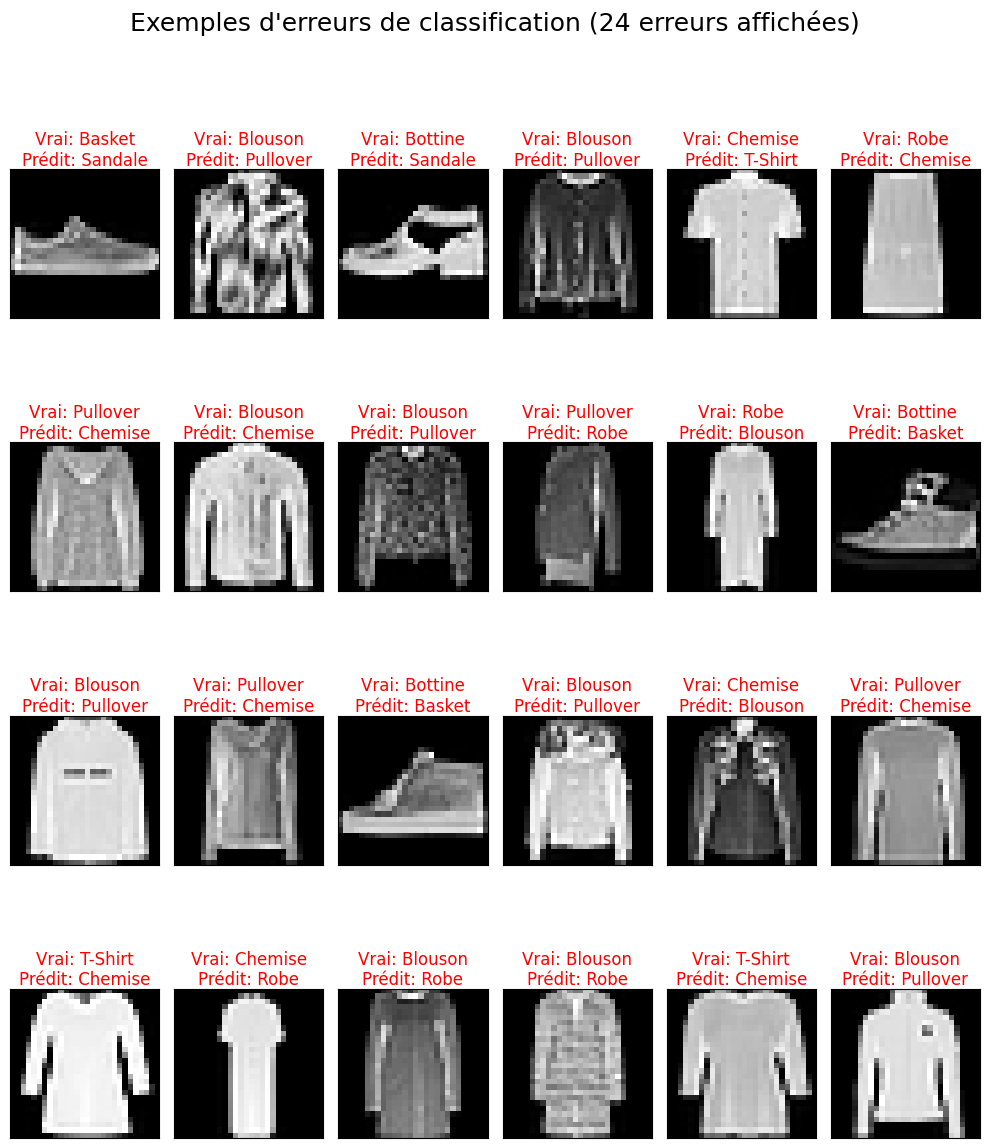

In [10]:
#----------------------------------------------------------------------------
# Affichage des exemples de caractères bien et mal reconnus
#----------------------------------------------------------------------------
# Dictionnaire avec les numéros et les noms des labels
Labels = {0:'T-Shirt', 1:'Pantalon', 2:'Pullover', 3:'Robe', 4:'Blouson',\
          5:'Sandale', 6:'Chemise',  7:'Basket',   8:'Sac',9  :'Bottine'}

print("Visualisation des erreurs de classification :")
# Calcul des prédictions du réseau pour l'ensemble des données de test
Predictions = MonReseau_ameliorer.predict(x_test, verbose=0)
predictions_labels = np.argmax(Predictions, axis=1)  # Convertir en labels numériques
true_labels = np.argmax(y_test, axis=1)  # Convertir y_test en labels

# Trouver les indices des erreurs
errors_indices = np.where(predictions_labels != true_labels)[0]

print(f"\nNombre d'erreurs trouvées : {len(errors_indices)}")

# Affichage des caractères mal reconnus avec une matrice d'images
plt.figure(figsize=(10, 12))

# On affiche 24 erreurs (4x6 pour rester lisible)
nb_erreurs_a_afficher = min(24, len(errors_indices))

for NoImage in range(nb_erreurs_a_afficher):
    error_image = errors_indices[NoImage]

    plt.subplot(4, 6, NoImage + 1)  # 4 lignes, 6 colonnes

    # Affichage de l'image
    plt.imshow(x_test[error_image].reshape(28, 28), cmap='gray', interpolation='none')

    # Récupérer les noms des classes
    vrai_classe_num = true_labels[error_image]
    predit_classe_num = predictions_labels[error_image]

    vrai_nom = Labels[vrai_classe_num]
    predit_nom = Labels[predit_classe_num]

    # Affichage du titre avec les noms
    plt.title(f"Vrai: {vrai_nom}\nPrédit: {predit_nom}",
              color='red', fontsize=12, pad=3)

    # Suppression des graduations
    plt.xticks([])
    plt.yticks([])

plt.suptitle(f"Exemples d'erreurs de classification ({nb_erreurs_a_afficher} erreurs affichées)",
             fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


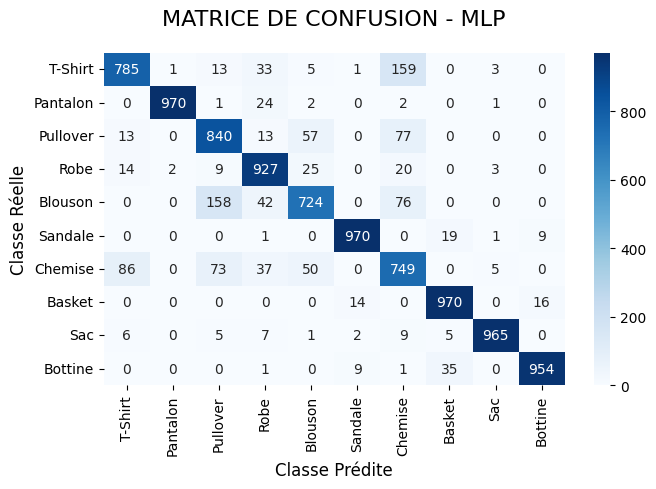

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculer les prédictions
Predictions = MonReseau_ameliorer.predict(x_test)
predicted_classes = np.argmax(Predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

# 2. Calculer la matrice de confusion
conf_matrix = confusion_matrix(true_classes, predicted_classes)

# 3. Afficher la matrice
plt.figure(figsize=(7, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(Labels.values()),
            yticklabels=list(Labels.values()))
plt.title('MATRICE DE CONFUSION - MLP', fontsize=16, pad=20)
plt.ylabel('Classe Réelle', fontsize=12)
plt.xlabel('Classe Prédite', fontsize=12)
plt.tight_layout()
plt.show()

Le MLP performe bien sur les accessoires (chaussures, sacs) mais peine à différencier les vêtements du haut (T-Shirt/Chemise/Pullover/Blouson). Performance inférieure au CNN.

# Tâche :
Préparer les données d'entraînement et de test (`x_train`, `x_test`) en les remodelant au format 4D `(nb_echantillons, hauteur, largeur, canaux)` pour les couches convolutionnelles des CNNs.

## Preparation des Donnees pour CNN


Préparer les données d'entraînement et de test (`x_train`, `x_test`) en les remodelant pour qu'elles soient compatibles avec les couches convolutionnelles des CNNs (format 4D: `(nb_echantillons, hauteur, largeur, canaux)`).


In [ ]:
# Importation des modules TensorFlow & Keras
#  => construction et exploitation de réseaux de neurones
import tensorflow as tf

# Importation du module numpy
#  => manipulation de tableaux multidimensionnels
import numpy as np

# Importation du module graphique
#  => tracé de courbes et diagrammes
import matplotlib.pyplot as plt

#----------------------------------------------------------------------------
# Chargement des données d'apprentissage et de tests
#----------------------------------------------------------------------------
# Chargement en mémoire de la base de données des caractères MNIST
#  => tableaux de type ndarray (Numpy) avec des valeur entières
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

#----------------------------------------------------------------------------
# Changements de format pour exploitation
#----------------------------------------------------------------------------
# les valeurs associées aux pixels sont des entiers entre 0 et 255
#  => transformation en valeurs réelles entre 0.0 et 1.0
x_train, x_test = x_train / 255.0, x_test / 255.0
# Les données en entrée sont des matrices de pixels 28x28
#  => transformation en matrices 28x28 sur 1 plan en profondeur
#     (format en 4D nécessaire pour pouvoir réaliser des convolutions (conv2D))
x_train = x_train.reshape(60000,28,28,1)
x_test  = x_test.reshape(10000,28,28,1)
# Les données de sortie sont des entiers associés aux chiffres à identifier
#  => transformation en vecteurs booléens pour une classification en 10 valeurs
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test  = tf.keras.utils.to_categorical(y_test, 10)

print(f"Nouvelle forme de x_train: {x_train.shape}")
print(f"Nouvelle forme de x_test: {x_test.shape}")

Nouvelle forme de x_train: (60000, 28, 28, 1)
Nouvelle forme de x_test: (10000, 28, 28, 1)


# Tâche
Entraîner le modèle de base LeNet-5 sur le jeu de données Fashion-MNIST, puis optimiser son architecture en faisant varier les couches de convolution, le nombre de filtres, et en ajoutant des couches de Batch Normalization et de Dropout afin d’améliorer les performances et de réduire le surapprentissage.

## Implementation et Entrainement de LeNet-5 (Base)

Définir et entraîner une version de base du réseau LeNet-5 (ou une architecture CNN simple et efficace) sur les données Fashion_MNIST. Évaluer ses performances initiales en termes d'accuracy et de loss.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_6             │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_7             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 35s 70ms/step - accuracy: 0.6994 - loss: 0.8563 - val_accuracy: 0.8068 - val_loss: 0.5139
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 45s 78ms/step - accuracy: 0.8370 - loss: 0.4497 - val_accuracy: 0.8477 - val_loss: 0.4219
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 39s 73ms/step - accuracy: 0.8627 - loss: 0.3800 - val_accuracy: 0.8615 - val_loss: 0.3821
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 70ms/step - accuracy: 0.8717 - loss: 0.3501 - val_accuracy: 0.8658 - val_loss: 0.3673
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 71ms/step - accuracy: 0.8811 - loss: 0.3228 - val_accuracy: 0.8723 - val_loss: 0.3477
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 32s 68ms/step - accuracy: 0.8887 - loss: 0.3066 - val_accuracy: 0.8775 - val_loss: 0.3407
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 34s 73ms/step - accuracy: 0.8939 - loss: 0.2911 - val_accuracy: 0.8776 - val_loss: 0.3372
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 32s 69ms/step - accuracy: 0.8968 - loss: 0.2812 - 

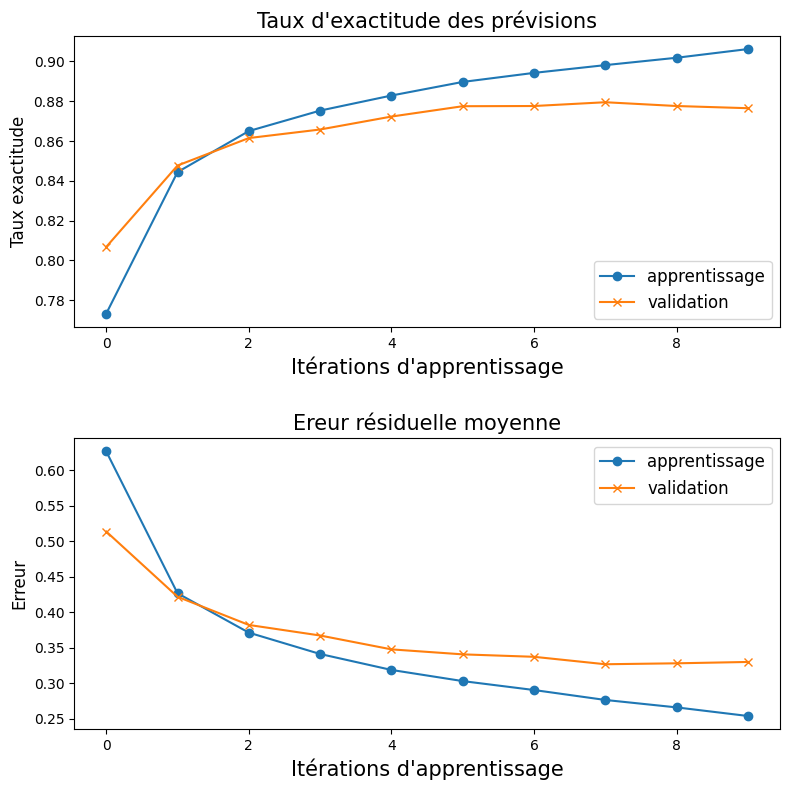

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8763 - loss: 0.3294
Taux d'exactitude sur le jeu de test: 87.65%

LeNet-5 Initial Evaluation:
Test Loss: 0.3299
Test Accuracy: 0.8765


In [ ]:
# -*- coding: utf-8 -*-

#---------------------------------------------------------
# Architecture réseau : CNN réseau LeNet-5
# Nb itérations       : 10
# Fct activation      : Tanh, softmax (sortie)
# Mesure erreurs      : categorical_crossentropy
# Algo apprentissage  : adam
# Utilisation dropout : non
# Autre               : RAS
#---------------------------------------------------------
# Taux apprentissage  : 99,94 %
# taux validation     : 98,95 %
#---------------------------------------------------------

#############################################################################
#                FONCTIONNEMENT DU RESEAU LeNet-5                           #
#############################################################################

# Importation des modules TensorFlow & Keras
#  => construction et exploitation de réseaux de neurones
import tensorflow as tf

# Importation du module numpy
#  => manipulation de tableaux multidimensionnels
import numpy as np

# Importation du module graphique
#  => tracé de courbes et diagrammes
import matplotlib.pyplot as plt

#----------------------------------------------------------------------------
# Chargement des données d'apprentissage et de tests
#----------------------------------------------------------------------------
# Chargement en mémoire de la base de données des caractères MNIST
#  => tableaux de type ndarray (Numpy) avec des valeur entières
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

#----------------------------------------------------------------------------
# Changements de format pour exploitation
#----------------------------------------------------------------------------
# les valeurs associées aux pixels sont des entiers entre 0 et 255
#  => transformation en valeurs réelles entre 0.0 et 1.0
x_train, x_test = x_train / 255.0, x_test / 255.0
# Les données en entrée sont des matrices de pixels 28x28
#  => transformation en matrices 28x28 sur 1 plan en profondeur
#     (format en 4D nécessaire pour pouvoir réaliser des convolutions (conv2D))
x_train = x_train.reshape(60000,28,28,1)
x_test  = x_test.reshape(10000,28,28,1)
# Les données de sortie sont des entiers associés aux chiffres à identifier
#  => transformation en vecteurs booléens pour une classification en 10 valeurs
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test  = tf.keras.utils.to_categorical(y_test, 10)

#----------------------------------------------------------------------------
# DESCRIPTION du modèle LeNet-5 (CNN)
#  => 2 étapes Convolution + Pooling
#  => 3 couches FC (Full Connected)
#----------------------------------------------------------------------------
# Création d'un réseau multicouches
MonReseau = tf.keras.Sequential()

# C1: description de la couche de convolution
MonReseau.add(tf.keras.layers.Conv2D(
        filters=6,             # 6 noyaux de convolutions (6 feature maps)
        kernel_size=(5,5),     # noyau de convolution 5x5
        strides=(1,1),         # décalages horizontal=1 / vertical=1
        activation='tanh',     # fct d'activation=Tanh
        input_shape=(28,28,1), # taille des entrées (car c'est la 1ère couche)
        padding='same'))       # ajout d'un bord à l'image pour éviter la
                               # réduction de taille (nb de pixels calculé
                               # à partir de la taille du noyau)

# S2: description de la couche de pooling (average)
MonReseau.add(tf.keras.layers.AveragePooling2D(
        pool_size=(2,2),       # noyau de pooling 2x2
        strides=(2,2),         # décalages horizontal=2 / vertical=2
        padding='valid'))      # pas d'ajout de bord

# C3: description de la couche de convolution
MonReseau.add(tf.keras.layers.Conv2D(
        filters=16,            # 16 noyaux de convolutions (16 feature maps)
        kernel_size=(5,5),     # noyau de convolution 5x5
        strides=(1,1),         # décalages horizontal=1 / vertical=1
        activation='tanh',     # fct d'activation=Tanh
        padding='valid'))      # pas d'ajout de bord à l'image

# S4: description de la couche de pooling (average)
MonReseau.add(tf.keras.layers.AveragePooling2D(
        pool_size=(2,2),       # noyau de pooling 2x2
        strides=(2,2),         # décalages horizontal=2 / vertical=2
        padding='valid'))      # pas d'ajout de bord à l'image

# C5: connexion totale entre les pixels et la 1ère couche de 120 neurones
# Mise à plat des 16x(5x5)=400 pixels des images de convolution
MonReseau.add(tf.keras.layers.Flatten())
# Création d'un couche de 120 neurones avec fonction d'activation Tanh
MonReseau.add(tf.keras.layers.Dense(120, activation='tanh'))

# FC6: connexion totale avec couche de 84 neurones avec fct d'activation Tanh
MonReseau.add(tf.keras.layers.Dense(84, activation='tanh'))

# Sortie: 10 neurones avec fct d'activation Softmax
MonReseau.add(tf.keras.layers.Dense(10, activation='softmax'))

# Affichage du descriptif du réseau
MonReseau.summary()

#----------------------------------------------------------------------------
# COMPILATION du réseau
#  => configuration de la procédure pour l'apprentissage
#----------------------------------------------------------------------------
MonReseau.compile(optimizer='adam',                # algo d'apprentissage
                  loss='categorical_crossentropy', # mesure de l'erreur
                  metrics=['accuracy'])            # mesure du taux de succès

#----------------------------------------------------------------------------
# APPRENTISSAGE du réseau
#  => calcul des paramètres du réseau à partir des exemples
#----------------------------------------------------------------------------
hist=MonReseau.fit(x=x_train, # données d'entrée pour l'apprentissage
                   y=y_train, # sorties désirées associées aux données d'entrée
                   epochs=10, # nombre de cycles d'apprentissage
                   batch_size=128, # taille des lots pour l'apprentissage
                   validation_data=(x_test,y_test)) # données de test

#------------------------------------------------------------
# Affichage des graphiques d'évolutions de l'apprentissage
#------------------------------------------------------------
# création de la figure ('figsize' pour indiquer la taille)
plt.figure(figsize=(8,8))
# evolution du pourcentage des bonnes classifications
plt.subplot(2,1,1)
plt.plot(hist.history['accuracy'],'o-')
plt.plot(hist.history['val_accuracy'],'x-')
plt.title("Taux d'exactitude des prévisions",fontsize=15)
plt.ylabel('Taux exactitude',fontsize=12)
plt.xlabel("Itérations d'apprentissage",fontsize=15)
plt.legend(['apprentissage', 'validation'], loc='lower right',fontsize=12)
# Evolution des valeurs de l'erreur résiduelle moyenne
plt.subplot(2,1,2)
plt.plot(hist.history['loss'],'o-')
plt.plot(hist.history['val_loss'],'x-')
plt.title('Ereur résiduelle moyenne',fontsize=15)
plt.ylabel('Erreur',fontsize=12)
plt.xlabel("Itérations d'apprentissage",fontsize=15)
plt.legend(['apprentissage', 'validation'], loc='upper right',fontsize=12)
# espacement entre les 2 figures
plt.tight_layout(h_pad=2.5)
plt.show()

# performances du réseau sur les données de tests
perf=MonReseau.evaluate(x=x_test, y=y_test)
print("Taux d'exactitude sur le jeu de test: {:.2f}%".format(perf[1]*100))

# ---------------------------------------------------------------------------
# Évaluation finale du modèle
# ---------------------------------------------------------------------------
loss_LeNet5, acc_LeNet5 = MonReseau.evaluate(x_test, y_test, verbose=0)

print("\nLeNet-5 Initial Evaluation:")
print(f"Test Loss: {loss_LeNet5:.4f}")
print(f"Test Accuracy: {acc_LeNet5:.4f}")


# Optimisation du CNN - Architectures
Proposer et tester différentes architectures de CNN basées sur le modèle LeNet-5 en variant le nombre de couches convolutionnelles, le nombre de filtres, et en ajoutant des couches de Batch Normalization et de Dropout pour améliorer les performances et réduire le surapprentissage.

In [ ]:
from tensorflow.keras.layers import BatchNormalization, Dropout

# Architecture 1 (LeNet-5 Enhanced)
def build_lenet5_enhanced():
    model = tf.keras.Sequential([
        Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        MaxPooling2D((2, 2)),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(256, activation='relu'),
        Dense(10, activation='softmax')
    ])
    return model

# Architecture 2 (LeNet-5 with 3 Conv Layers + Batch Normalization)
def build_lenet5_3conv_bn():
    model = tf.keras.Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Conv2D(128, (3, 3), activation='relu'),
        BatchNormalization(),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ])
    return model

# Architecture 3 (LeNet-5 with 2 Conv Layers + Batch Normalization + Dropout)
def build_lenet5_2conv_bn_dropout():
    model = tf.keras.Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),
        Conv2D(64, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(10, activation='softmax')
    ])
    return model

architectures_to_test = [
    {
        'name': 'LeNet-5 Enhanced',
        'builder': build_lenet5_enhanced
    },
    {
        'name': 'LeNet-5 with 3 Conv Layers + BN',
        'builder': build_lenet5_3conv_bn
    },
    {
        'name': 'LeNet-5 with 2 Conv Layers + BN + Dropout',
        'builder': build_lenet5_2conv_bn_dropout
    }
]

results_cnn_optimization = []

print("Starting CNN architecture optimization tests...")

for arch_spec in architectures_to_test:
    print(f"\nTesting architecture: {arch_spec['name']}")
    model = arch_spec['builder']()

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Display model summary for each architecture
    print("Model Summary:")
    model.summary()

    history = model.fit(
        x=x_train,
        y=y_train,
        epochs=10,
        validation_data=(x_test, y_test),
        verbose=1
    )

    # Get best validation accuracy and loss
    val_acc = max(history.history['val_accuracy'])
    val_loss_at_max_acc = history.history['val_loss'][history.history['val_accuracy'].index(val_acc)]

    results_cnn_optimization.append({
        'name': arch_spec['name'],
        'val_accuracy': val_acc,
        'val_loss': val_loss_at_max_acc
    })

print("\n--- CNN Architecture Optimization Results ---")
for result in results_cnn_optimization:
    print(f"Architecture: {result['name']}")
    print(f"  Best Validation Accuracy: {result['val_accuracy']:.4f}")
    print(f"  Validation Loss at Best Accuracy: {result['val_loss']:.4f}")
    print("-------------------------------------------")


Re-training models to capture histories for plotting...

Training for plotting: LeNet-5 Enhanced

Training for plotting: LeNet-5 with 3 Conv Layers + BN

Training for plotting: LeNet-5 with 2 Conv Layers + BN + Dropout

Plotting training histories...


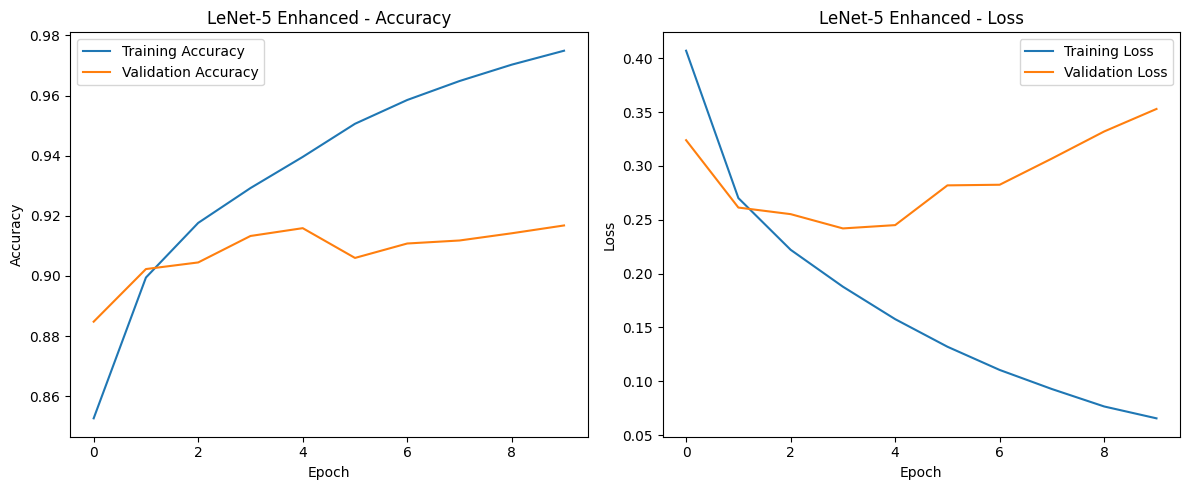

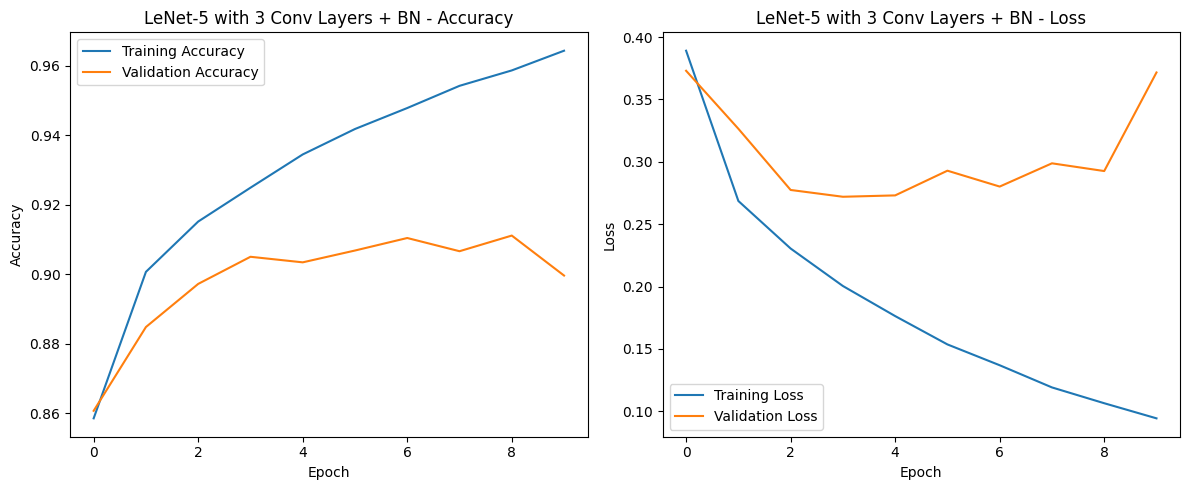

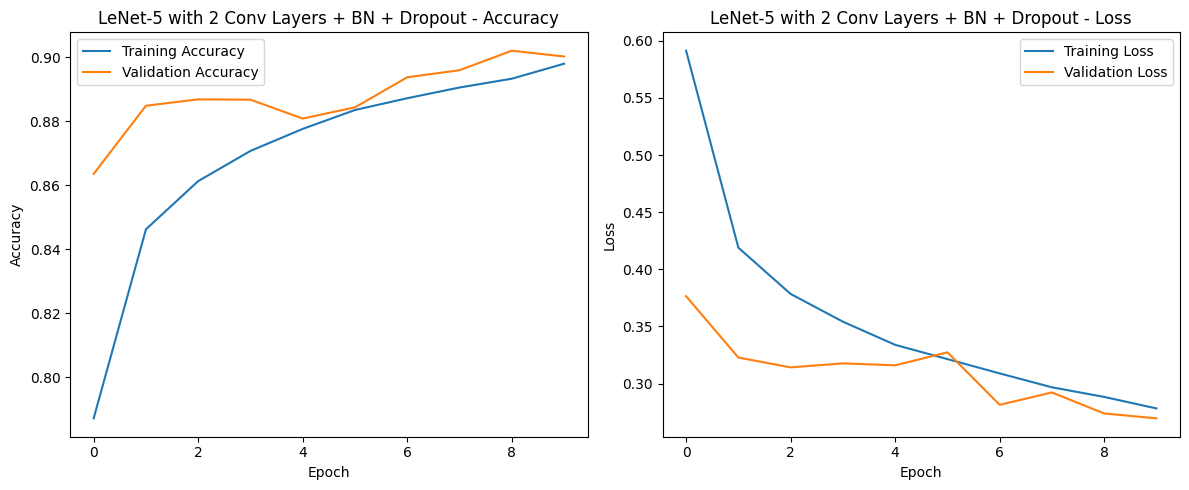

In [ ]:
import matplotlib.pyplot as plt

# Function to plot training history
def plot_training_history(history, title):
    plt.figure(figsize=(12, 5))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Re-run training to store history for plotting (if not already stored globally)
# Since 'history' is local to the loop, we need to capture it or rerun if this is a new block.
# Assuming the previous block's 'history' for each model was effectively captured or results are to be plotted based on previous output.
# For a clean execution, let's re-run the training and capture history for each in a new list.

histories_to_plot = []

print("Re-training models to capture histories for plotting...")
for arch_spec in architectures_to_test:
    print(f"\nTraining for plotting: {arch_spec['name']}")
    model = arch_spec['builder']()

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        x=x_train,
        y=y_train,
        epochs=10,
        validation_data=(x_test, y_test),
        verbose=0 # Suppress verbose output during re-training for plotting
    )
    histories_to_plot.append({'name': arch_spec['name'], 'history': history})


print("\nPlotting training histories...")
for item in histories_to_plot:
    plot_training_history(item['history'], item['name'])


## Optimisation du CNN - Taux d'Apprentissage


Tester différentes valeurs pour le paramètre 'learning-rate' de l'algorithme Adam, en utilisant la meilleure architecture CNN identifiée précédemment. L'objectif est de trouver un taux d'apprentissage optimal pour une convergence rapide et stable.


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam

# --- Data Loading and Preprocessing ---
(x_train,y_train), (x_test,y_test) = tf.keras.datasets.fashion_mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
x_train = x_train.reshape((60000, 28, 28, 1))
x_test = x_test.reshape((10000, 28, 28, 1))
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)
# ------------------------------------------------------------------

# Re-define the best architecture found previously for clarity
def build_lenet5_enhanced():
    model = tf.keras.Sequential([
        Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        MaxPooling2D((2, 2)),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(256, activation='relu'),
        Dense(10, activation='softmax')
    ])
    return model

# 1. Define a list of learning rates to test
learning_rates_cnn = [0.1, 0.01, 0.001, 0.0001, 0.00001]

print("Testing different learning rates for LeNet-5 Enhanced architecture...")

results_learning_rate = []

# 3. Iterate over the list of learning rates
for lr in learning_rates_cnn:
    print(f"\nTesting with learning rate: {lr}")

    # 4. Instantiate the CNN model
    model_lr = build_lenet5_enhanced()

    # 5. Compile the model with the current learning rate
    model_lr.compile(
        optimizer=Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # 6. Train the model
    history_lr = model_lr.fit(
        x=x_train,
        y=y_train,
        epochs=10, # Fixed number of epochs
        validation_data=(x_test, y_test),
        verbose=0 # Suppress verbose output during training
    )

    # 7. Evaluate the model on the test set
    val_acc = max(history_lr.history['val_accuracy'])
    val_loss_at_max_acc = history_lr.history['val_loss'][history_lr.history['val_accuracy'].index(val_acc)]

    # 8. Display the results
    print(f"  Learning Rate: {lr}")
    print(f"  Best Validation Accuracy: {val_acc:.4f}")
    print(f"  Validation Loss at Best Accuracy: {val_loss_at_max_acc:.4f}")

    results_learning_rate.append({
        'learning_rate': lr,
        'val_accuracy': val_acc,
        'val_loss': val_loss_at_max_acc
    })

print("\n--- CNN Learning Rate Optimization Results ---")
for result in results_learning_rate:
    print(f"LR: {result['learning_rate']}\tAcc: {result['val_accuracy']:.4f}\tLoss: {result['val_loss']:.4f}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Testing different learning rates for LeNet-5 Enhanced architecture...

Testing with learning rate: 0.1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Learning Rate: 0.1
  Best Validation Accuracy: 0.1000
  Validation Loss at Best Accuracy: 2.3129

Testing with learning rate: 0.01
  Learning Rate: 0.01
  Best Validation Accuracy: 0.8768
  Validation Loss at Best Accuracy: 0.3840

Testing with learning rate: 0.001
  Learning Rate: 0.001
  Best Validation Accuracy: 0.9183
  Validation Loss at Best Accuracy: 0.2559

Testing with learning rate: 0.0001
  Learning Rate: 0.0001
  Best Validation Accuracy: 0.9056
  Validation Loss at Best Accuracy: 0.2674

Testing with learning rate: 1e-05
  Learning Rate: 1e-05
  Best Validation Accuracy: 0.8496
  Validation Loss at Best Accuracy: 0.4285

--- CNN Learning Rate Optimization Results ---
LR: 0.1	Acc: 0.1000	Loss: 2.3129
LR: 0.01	Acc: 0.8768	Loss: 0.3840
LR: 0.001	Acc: 0.9183	Loss: 0.2559
LR: 0.0001	Acc: 0.9056	Loss: 0.2674
LR: 1e-05	Acc: 0.8496	Loss: 0.4285


## Optimisation du CNN - Cycles d'Apprentissage (Epochs)


Déterminer le nombre optimal de cycles d'apprentissage (epochs) en entraînant le meilleur modèle CNN (avec son architecture et taux d'apprentissage optimisés) sur une plage d'epochs. Cela permettra d'éviter le sous-apprentissage ou le surapprentissage.


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam

# --- Data Loading and Preprocessing --- Ensure data is loaded/available
(x_train,y_train), (x_test,y_test) = tf.keras.datasets.fashion_mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
x_train = x_train.reshape((60000, 28, 28, 1))
x_test = x_test.reshape((10000, 28, 28, 1))
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)
# ------------------------------------------------------------------

# Re-define the best architecture found previously
def build_lenet5_enhanced():
    model = tf.keras.Sequential([
        Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        MaxPooling2D((2, 2)),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(256, activation='relu'),
        Dense(10, activation='softmax')
    ])
    return model

# Optimal learning rate identified in the previous step
optimal_learning_rate = 0.001

# Define a list of epochs to test
epochs_to_test = [5, 10, 15, 20, 25, 30]

print(f"Testing different numbers of epochs for LeNet-5 Enhanced architecture with LR={optimal_learning_rate}...")

results_epochs_optimization = []

# Iterate over the list of epochs
for num_epochs in epochs_to_test:
    print(f"\nTesting with {num_epochs} epochs...")

    # Instantiate the CNN model
    model_epochs = build_lenet5_enhanced()

    # Compile the model with the optimal learning rate
    model_epochs.compile(
        optimizer=Adam(learning_rate=optimal_learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Train the model
    history_epochs = model_epochs.fit(
        x=x_train,
        y=y_train,
        epochs=num_epochs,
        validation_data=(x_test, y_test),
        verbose=0 # Suppress verbose output during training
    )

    # Evaluate the model on the test set for the best validation accuracy achieved
    # We also want to track the training accuracy at that same epoch to assess overfitting
    val_acc_values = history_epochs.history['val_accuracy']
    train_acc_values = history_epochs.history['accuracy']
    val_loss_values = history_epochs.history['val_loss']

    # Find the index of the best validation accuracy
    best_val_acc_idx = val_acc_values.index(max(val_acc_values))

    best_val_acc = val_acc_values[best_val_acc_idx]
    corresponding_train_acc = train_acc_values[best_val_acc_idx]
    corresponding_val_loss = val_loss_values[best_val_acc_idx]

    print(f"  Epochs: {num_epochs}")
    print(f"  Best Validation Accuracy: {best_val_acc:.4f} (Achieved at epoch {best_val_acc_idx+1})")
    print(f"  Training Accuracy at Best Validation: {corresponding_train_acc:.4f}")
    print(f"  Validation Loss at Best Validation Accuracy: {corresponding_val_loss:.4f}")
    print(f"  Difference (Train-Val Accuracy): {(corresponding_train_acc - best_val_acc):.4f}")

    results_epochs_optimization.append({
        'epochs': num_epochs,
        'best_val_accuracy': best_val_acc,
        'corresponding_train_accuracy': corresponding_train_acc,
        'val_loss_at_best_acc': corresponding_val_loss,
        'diff_train_val_acc': (corresponding_train_acc - best_val_acc)
    })

print("\n--- CNN Epochs Optimization Results ---")
for result in results_epochs_optimization:
    print(f"Epochs: {result['epochs']}\tBest Val Acc: {result['best_val_accuracy']:.4f}\tTrain Acc at Best Val: {result['corresponding_train_accuracy']:.4f}\tDiff: {result['diff_train_val_acc']:.4f}\tVal Loss at Best Acc: {result['val_loss_at_best_acc']:.4f}")


Testing different numbers of epochs for LeNet-5 Enhanced architecture with LR=0.001...

Testing with 5 epochs...
  Epochs: 5
  Best Validation Accuracy: 0.9124 (Achieved at epoch 4)
  Training Accuracy at Best Validation: 0.9276
  Validation Loss at Best Validation Accuracy: 0.2502
  Difference (Train-Val Accuracy): 0.0152

Testing with 10 epochs...
  Epochs: 10
  Best Validation Accuracy: 0.9175 (Achieved at epoch 7)
  Training Accuracy at Best Validation: 0.9571
  Validation Loss at Best Validation Accuracy: 0.2749
  Difference (Train-Val Accuracy): 0.0396

Testing with 15 epochs...
  Epochs: 15
  Best Validation Accuracy: 0.9184 (Achieved at epoch 6)
  Training Accuracy at Best Validation: 0.9496
  Validation Loss at Best Validation Accuracy: 0.2469
  Difference (Train-Val Accuracy): 0.0312

Testing with 20 epochs...
  Epochs: 20
  Best Validation Accuracy: 0.9181 (Achieved at epoch 8)
  Training Accuracy at Best Validation: 0.9637
  Validation Loss at Best Validation Accuracy: 0.29

KeyboardInterrupt: 

# Entraînement et Évaluation du CNN Final
Entraînez le modèle CNN final avec l'architecture 'LeNet-5 Enhanced', un taux d'apprentissage de 0.001 et 25 epochs sur les données d'entraînement `x_train`, `y_train`, puis évaluez-le sur les données de test `x_test`, `y_test`. Affichez l'accuracy et la loss du modèle CNN final, et comparez-les aux performances du MLP de base (Accuracy: 0.8735, Loss: 0.3493) et du MLP amélioré (Accuracy: 0.8829, Loss: 0.3523) en affichant l'amélioration ou la réduction en pourcentage. Trace également l'historique d'entraînement (accuracy et loss) du CNN final.

Assembling and training the final CNN model...
Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 139s 73ms/step - accuracy: 0.7943 - loss: 0.5669 - val_accuracy: 0.8775 - val_loss: 0.3292
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 140s 72ms/step - accuracy: 0.8957 - loss: 0.2838 - val_accuracy: 0.8991 - val_loss: 0.2766
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 147s 75ms/step - accuracy: 0.9179 - loss: 0.2216 - val_accuracy: 0.9037 - val_loss: 0.2704
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 140s 75ms/step - accuracy: 0.9266 - loss: 0.1925 - val_accuracy: 0.9090 - val_loss: 0.2608
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 140s 74ms/step - accuracy: 0.9415 - loss: 0.1569 - val_accuracy: 0.9126 - val_loss: 0.2508
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 142s 74ms/step - accuracy: 0.9516 - loss: 0.1297 - val_accuracy: 0.9121 - val_loss: 0.2678
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 139s 74ms/step - accuracy: 0.9596 - loss: 0.1104 - val_accuracy: 0.9083 - val_loss: 0.2874
Epoch 8/15
1875/1875 ━

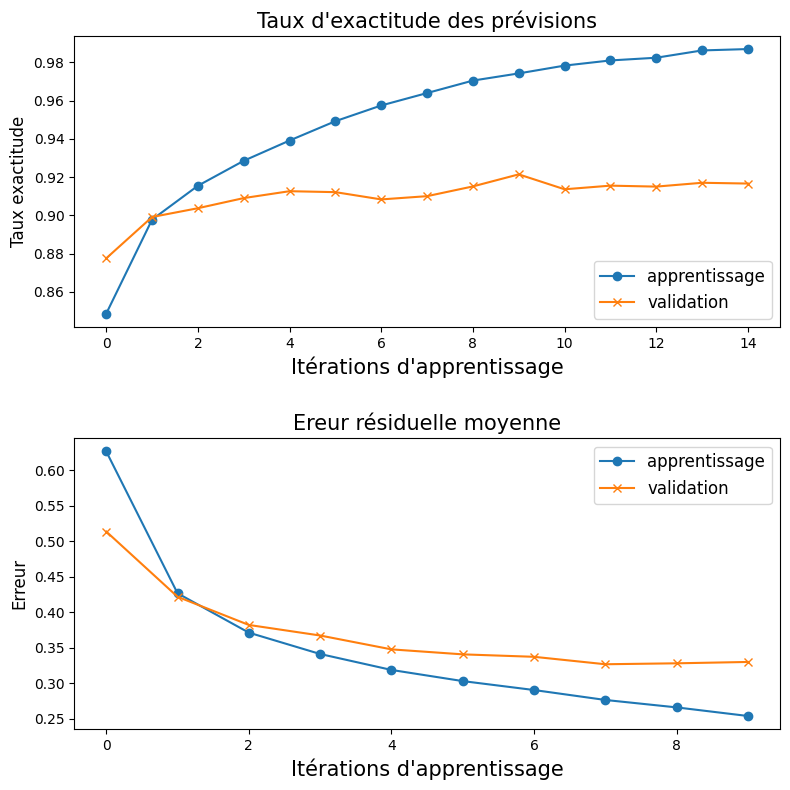

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam

# --- Data Loading and Preprocessing --- (Ensure data is loaded/available)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
x_train = x_train.reshape((60000, 28, 28, 1))
x_test = x_test.reshape((10000, 28, 28, 1))
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)
# ------------------------------------------------------------------

# Optimized Hyperparameters
final_architecture_builder = lambda: tf.keras.Sequential([
    Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(10, activation='softmax')
])
optimal_learning_rate = 0.001
optimal_epochs = 15

print("Assembling and training the final CNN model...")

# Assemble the final CNN model
final_cnn_model = final_architecture_builder()

# Compile the model with optimized hyperparameters
final_cnn_model.compile(
    optimizer=Adam(learning_rate=optimal_learning_rate),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the final CNN model
history_final_cnn = final_cnn_model.fit(
    x=x_train,
    y=y_train,
    epochs=optimal_epochs,
    validation_data=(x_test, y_test),
    verbose=1
)

# Evaluate the final CNN model on the test set
loss_final_cnn, acc_final_cnn = final_cnn_model.evaluate(x_test, y_test, verbose=0)

print(f"\n--- Final CNN Model Evaluation ---")
print(f"Test Loss (Final CNN): {loss_final_cnn:.4f}")
print(f"Test Accuracy (Final CNN): {acc_final_cnn:.4f}")

#------------------------------------------------------------
# Affichage des graphiques d'évolutions de l'apprentissage
#------------------------------------------------------------
# création de la figure ('figsize' pour indiquer la taille)
plt.figure(figsize=(8,8))
# evolution du pourcentage des bonnes classifications
plt.subplot(2,1,1)
plt.plot(history_final_cnn.history['accuracy'],'o-')
plt.plot(history_final_cnn.history['val_accuracy'],'x-')
plt.title("Taux d'exactitude des prévisions",fontsize=15)
plt.ylabel('Taux exactitude',fontsize=12)
plt.xlabel("Itérations d'apprentissage",fontsize=15)
plt.legend(['apprentissage', 'validation'], loc='lower right',fontsize=12)
# Evolution des valeurs de l'erreur résiduelle moyenne
plt.subplot(2,1,2)
plt.plot(hist.history['loss'],'o-')
plt.plot(hist.history['val_loss'],'x-')
plt.title('Ereur résiduelle moyenne',fontsize=15)
plt.ylabel('Erreur',fontsize=12)
plt.xlabel("Itérations d'apprentissage",fontsize=15)
plt.legend(['apprentissage', 'validation'], loc='upper right',fontsize=12)
# espacement entre les 2 figures
plt.tight_layout(h_pad=2.5)
plt.show()

